# Neuro-BOA Adaptativo para NPFSP — Kaggle/Colab

Implementação experimental com:

- leitura automática de **5 instâncias** da pasta `Small/`;
- **BOA-Q** e **Neuro-Q** treinados com a elite;
- seleção de soluções **boas e distantes da elite**;
- **BOA-D** e **Neuro-D** treinados com diversidade útil;
- duas meta-redes para escolher **BOA ou Neuro**:
  - uma para qualidade;
  - uma para diversidade;
- geração de **soluções completas** por um único gerador;
- Optuna para ajuste offline dos hiperparâmetros;
- experimentos comparativos:
  1. BOA puro;
  2. Neuro puro;
  3. BOA-Q + BOA-D;
  4. Neuro-Q + Neuro-D;
  5. Adaptativo BOA/Neuro para qualidade e diversidade.


In [ ]:

!pip -q install optuna

import os, math, random, copy, time
from dataclasses import dataclass
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import optuna

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)


Dispositivo: cpu


In [8]:
from pathlib import Path

SMALL_DIR = Path(
    "/content/Small"
)

N_SMALL_INSTANCES = 5

all_small_files = sorted(SMALL_DIR.glob("*.txt"))

assert len(all_small_files) >= N_SMALL_INSTANCES, (
    f"Esperava pelo menos {N_SMALL_INSTANCES} arquivos .txt em {SMALL_DIR}, "
    f"mas encontrei apenas {len(all_small_files)}."
)

files = all_small_files[:N_SMALL_INSTANCES]

print(
    f"{len(all_small_files)} arquivos .txt encontrados na pasta Small; "
    f"{len(files)} serão utilizados:"
)
for f in files:
    print("-", f.name)


420 arquivos .txt encontrados na pasta Small; 5 serão utilizados:
- I_2_10_2_1.txt
- I_2_10_2_2.txt
- I_2_10_2_3.txt
- I_2_10_2_4.txt
- I_2_10_2_5.txt


In [9]:

@dataclass
class Instance:
    name: str
    group: str
    n_jobs: int
    n_machines: int
    processing: np.ndarray
    due_dates: np.ndarray
    metadata_line: int | None = None

def read_instance(path: Path) -> Instance:
    raw = [ln.strip() for ln in path.read_text(encoding="utf-8", errors="ignore").splitlines()
           if ln.strip()]

    head = raw[0].split()
    n_jobs, n_machines = map(int, head[:2])

    due_idx = next(i for i, ln in enumerate(raw) if ln.lower().startswith("duedate"))
    pre = raw[1:due_idx]

    metadata_line = None
    proc_lines = []

    for ln in pre:
        vals = ln.split()
        if len(vals) == 1 and metadata_line is None:
            try:
                metadata_line = int(vals[0])
                continue
            except ValueError:
                pass
        if len(vals) >= 2 * n_machines:
            proc_lines.append(vals)

    if len(proc_lines) < n_jobs:
        raise ValueError(
            f"{path.name}: esperava {n_jobs} linhas de processamento; "
            f"encontrei {len(proc_lines)}."
        )

    processing = np.zeros((n_jobs, n_machines), dtype=np.int32)

    for j in range(n_jobs):
        vals = list(map(int, proc_lines[j][:2*n_machines]))
        pairs = [(vals[k], vals[k+1]) for k in range(0, len(vals), 2)]
        seen = set()
        for machine, ptime in pairs:
            processing[j, machine] = ptime
            seen.add(machine)
        if len(seen) != n_machines:
            raise ValueError(f"{path.name}: job {j} não contém todas as máquinas.")

    dd = []
    for ln in raw[due_idx+1:]:
        for token in ln.split():
            try:
                dd.append(int(token))
            except ValueError:
                pass

    if len(dd) < n_jobs:
        raise ValueError(f"{path.name}: faltam due dates.")

    return Instance(
        name=path.name,
        group=path.parent.name,
        n_jobs=n_jobs,
        n_machines=n_machines,
        processing=processing,
        due_dates=np.asarray(dd[:n_jobs], dtype=np.int32),
        metadata_line=metadata_line
    )

# Carrega as 5 instâncias Small
instances = {
    "Small": [
        read_instance(path)
        for path in files
    ]
}

SMALL_INSTANCES = instances["Small"]

assert len(SMALL_INSTANCES) == N_SMALL_INSTANCES, (
    f"Deveriam ter sido carregadas {N_SMALL_INSTANCES} instâncias, "
    f"mas foram carregadas {len(SMALL_INSTANCES)}."
)

print("Small carregadas:", len(SMALL_INSTANCES))

for inst in SMALL_INSTANCES:
    print(
        inst.name,
        inst.processing.shape,
        inst.due_dates.shape,
        "metadata:", inst.metadata_line
    )


Small carregadas: 5
I_2_10_2_1.txt (10, 2) (10,) metadata: 2
I_2_10_2_2.txt (10, 2) (10,) metadata: 2
I_2_10_2_3.txt (10, 2) (10,) metadata: 2
I_2_10_2_4.txt (10, 2) (10,) metadata: 2
I_2_10_2_5.txt (10, 2) (10,) metadata: 2



## Representação da solução

Cada indivíduo tem forma `[n_machines, n_jobs]`. Cada linha é uma permutação independente dos jobs naquela máquina.

Isso representa o **Non-Permutation Flow Shop** porque máquinas distintas podem executar os jobs em ordens distintas.


In [10]:

def random_individual(inst, rng):
    return np.vstack([
        rng.permutation(inst.n_jobs) for _ in range(inst.n_machines)
    ]).astype(np.int32)

def decode_npfs(ind, inst):
    """
    Decodificador via grafo de precedências.

    Nós: (job, máquina).
    Arestas:
      1) precedência tecnológica do job;
      2) ordem dos jobs em cada máquina.

    Se houver ciclo, a solução é inviável.
    """
    n, M = inst.n_jobs, inst.n_machines
    N = n * M

    succ = [[] for _ in range(N)]
    indeg = np.zeros(N, dtype=np.int32)

    def nid(j, m):
        return j * M + m

    # Precedência tecnológica: máquina 0 -> 1 -> ... -> M-1
    for j in range(n):
        for m in range(1, M):
            u, v = nid(j, m-1), nid(j, m)
            succ[u].append(v)
            indeg[v] += 1

    # Ordem da solução em cada máquina
    for m in range(M):
        seq = ind[m]
        for p in range(1, n):
            u, v = nid(int(seq[p-1]), m), nid(int(seq[p]), m)
            succ[u].append(v)
            indeg[v] += 1

    q = deque([u for u in range(N) if indeg[u] == 0])
    start = np.zeros(N, dtype=np.int64)
    finish = np.zeros(N, dtype=np.int64)
    processed = 0

    while q:
        u = q.popleft()
        processed += 1
        j, m = divmod(u, M)
        finish[u] = start[u] + int(inst.processing[j, m])

        for v in succ[u]:
            start[v] = max(start[v], finish[u])
            indeg[v] -= 1
            if indeg[v] == 0:
                q.append(v)

    if processed != N:
        return {
            "feasible": False,
            "makespan": float("inf"),
            "total_tardiness": float("inf"),
            "completion_jobs": None
        }

    completion = np.asarray([finish[nid(j, M-1)] for j in range(n)])
    makespan = int(completion.max())
    total_tardiness = int(np.maximum(completion - inst.due_dates, 0).sum())

    return {
        "feasible": True,
        "makespan": makespan,
        "total_tardiness": total_tardiness,
        "completion_jobs": completion
    }

def evaluate(ind, inst, objective="makespan"):
    d = decode_npfs(ind, inst)
    if not d["feasible"]:
        return 1e18
    if objective == "makespan":
        return float(d["makespan"])
    if objective == "tardiness":
        return float(d["total_tardiness"])
    raise ValueError("objective deve ser 'makespan' ou 'tardiness'")

# Teste unitário do decodificador usando apenas a primeira das 5 instâncias
rng = np.random.default_rng(42)
inst0 = SMALL_INSTANCES[0]
ind0 = random_individual(inst0, rng)
print(decode_npfs(ind0, inst0))


{'feasible': True, 'makespan': 1062, 'total_tardiness': 7734, 'completion_jobs': array([1053, 1062,  783, 1029,  566,  898,  879,  968,  734,  941])}


In [11]:

# ============================================================
# Distância Kendall e diversidade útil
# ============================================================
def kendall_distance_perm(a, b):
    n = len(a)
    pos = np.empty(n, dtype=np.int32)
    for i, x in enumerate(a):
        pos[int(x)] = i

    arr = [int(pos[int(x)]) for x in b]
    tmp = [0] * len(arr)

    def sort_count(lo, hi):
        if hi - lo <= 1:
            return 0
        mid = (lo + hi) // 2
        c = sort_count(lo, mid) + sort_count(mid, hi)
        i, j, k = lo, mid, lo
        while i < mid and j < hi:
            if arr[i] <= arr[j]:
                tmp[k] = arr[i]
                i += 1
            else:
                tmp[k] = arr[j]
                j += 1
                c += mid - i
            k += 1
        while i < mid:
            tmp[k] = arr[i]
            i += 1
            k += 1
        while j < hi:
            tmp[k] = arr[j]
            j += 1
            k += 1
        arr[lo:hi] = tmp[lo:hi]
        return c

    return sort_count(0, len(arr))

def individual_distance(a, b):
    M, n = a.shape
    denom = n * (n - 1) / 2
    if denom == 0:
        return 0.0
    return float(np.mean([
        kendall_distance_perm(a[m], b[m]) / denom
        for m in range(M)
    ]))

def distance_to_elite(ind, elite):
    if not elite:
        return 0.0
    return float(np.mean([individual_distance(ind, e) for e in elite]))

def population_diversity(pop, sample_pairs=80, rng=None):
    if len(pop) < 2:
        return 0.0
    rng = rng or np.random.default_rng()
    max_pairs = len(pop) * (len(pop) - 1) // 2
    k = min(sample_pairs, max_pairs)
    pairs = set()
    while len(pairs) < k:
        i, j = rng.integers(0, len(pop), size=2)
        if i == j:
            continue
        i, j = sorted((int(i), int(j)))
        pairs.add((i, j))
    return float(np.mean([
        individual_distance(pop[i], pop[j]) for i, j in pairs
    ]))

def select_diverse_good(pop, fitness, elite_count,
                        candidate_frac=0.35, diverse_count=None):
    """
    1) elite = melhores soluções
    2) candidatos = próximos bons indivíduos, excluindo elite
    3) mede distância de cada candidato à elite
    4) escolhe os mais distantes dentre os candidatos bons
    """
    order = np.argsort(fitness)
    elite_idx = order[:elite_count]
    elite = [pop[i] for i in elite_idx]

    n_candidates = max(1, int(round(len(pop) * candidate_frac)))
    cand_idx = order[elite_count:min(len(pop), elite_count+n_candidates)]

    if len(cand_idx) == 0:
        return elite, [], []

    scored = [(int(i), distance_to_elite(pop[int(i)], elite)) for i in cand_idx]
    scored.sort(key=lambda z: z[1], reverse=True)

    if diverse_count is None:
        diverse_count = elite_count

    chosen = scored[:min(diverse_count, len(scored))]
    diverse = [pop[i] for i, _ in chosen]
    scores = [s for _, s in chosen]
    return elite, diverse, scores


In [12]:

# ============================================================
# BOA: modelo bayesiano autoregressivo de primeira ordem
# ============================================================
class BayesianPermutationModel:
    """
    Para cada máquina aprende:
      P(primeiro job)
      P(job atual | job anterior)

    Na amostragem, jobs já usados são mascarados.
    """
    def __init__(self, n_jobs, n_machines, smoothing=1.0):
        self.n = n_jobs
        self.M = n_machines
        self.smoothing = smoothing
        self.first = np.ones((self.M, self.n)) / self.n
        self.trans = np.ones((self.M, self.n, self.n)) / self.n

    def fit(self, individuals):
        if not individuals:
            return

        first_counts = np.full(
            (self.M, self.n), self.smoothing, dtype=np.float64
        )
        trans_counts = np.full(
            (self.M, self.n, self.n), self.smoothing, dtype=np.float64
        )

        for ind in individuals:
            for m in range(self.M):
                seq = ind[m]
                first_counts[m, int(seq[0])] += 1
                for p in range(1, self.n):
                    a = int(seq[p-1])
                    b = int(seq[p])
                    trans_counts[m, a, b] += 1

        self.first = first_counts / first_counts.sum(axis=1, keepdims=True)
        self.trans = trans_counts / trans_counts.sum(axis=2, keepdims=True)

    def sample_machine(self, m, rng):
        used = np.zeros(self.n, dtype=bool)
        seq = []

        p = self.first[m].copy()
        x = int(rng.choice(self.n, p=p/p.sum()))
        seq.append(x)
        used[x] = True

        for _ in range(1, self.n):
            p = self.trans[m, x].copy()
            p[used] = 0.0
            if p.sum() <= 0:
                x = int(rng.choice(np.where(~used)[0]))
            else:
                p /= p.sum()
                x = int(rng.choice(self.n, p=p))
            seq.append(x)
            used[x] = True

        return np.asarray(seq, dtype=np.int32)

    def sample(self, rng):
        return np.vstack([
            self.sample_machine(m, rng) for m in range(self.M)
        ])


In [13]:

# ============================================================
# Neuro: MLP autoregressiva
# ============================================================
class NeuroPermutationMLP(nn.Module):
    def __init__(self, n_jobs, hidden=128, dropout=0.0):
        super().__init__()
        inp = 2*n_jobs + 2
        self.net = nn.Sequential(
            nn.Linear(inp, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_jobs)
        )

    def forward(self, x):
        return self.net(x)

def build_neuro_examples(individuals, n_jobs, n_machines):
    X, y = [], []

    for ind in individuals:
        for m in range(n_machines):
            used = np.zeros(n_jobs, dtype=np.float32)
            last = np.zeros(n_jobs, dtype=np.float32)

            for p in range(n_jobs):
                target = int(ind[m, p])
                feat = np.concatenate([
                    used,
                    last,
                    np.array([
                        p / max(1, n_jobs-1),
                        m / max(1, n_machines-1)
                    ], dtype=np.float32)
                ])
                X.append(feat)
                y.append(target)

                used[target] = 1.0
                last[:] = 0.0
                last[target] = 1.0

    if not X:
        return None, None

    return (
        torch.tensor(np.asarray(X), dtype=torch.float32),
        torch.tensor(np.asarray(y), dtype=torch.long)
    )

def train_neuro(model, individuals, n_jobs, n_machines,
                lr=1e-3, epochs=2, batch_size=256):
    X, y = build_neuro_examples(individuals, n_jobs, n_machines)
    if X is None:
        return

    X, y = X.to(DEVICE), y.to(DEVICE)

    # O learning rate informado aqui é apenas o valor INICIAL.
    # O otimizador e o scheduler ficam associados à própria rede e
    # persistem entre as gerações.
    if not hasattr(model, "_optimizer"):
        model._optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr
        )
        model._lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            model._optimizer,
            mode="min",
            factor=0.5,
            patience=3,
            min_lr=1e-6
        )

    opt = model._optimizer
    model.train()

    losses = []

    for _ in range(epochs):
        order = torch.randperm(len(X), device=DEVICE)
        Xs, ys = X[order], y[order]

        for s in range(0, len(Xs), batch_size):
            xb = Xs[s:s+batch_size]
            yb = ys[s:s+batch_size]

            logits = model(xb)
            loss = F.cross_entropy(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            losses.append(float(loss.detach().cpu()))

    # A própria evolução da loss controla o learning rate.
    if losses:
        mean_loss = float(np.mean(losses))
        model._lr_scheduler.step(mean_loss)

    return float(opt.param_groups[0]["lr"])

def neuro_sample(model, n_jobs, n_machines, rng, temperature=1.0):
    model.eval()
    all_machines = []

    with torch.no_grad():
        for m in range(n_machines):
            used = np.zeros(n_jobs, dtype=np.float32)
            last = np.zeros(n_jobs, dtype=np.float32)
            seq = []

            for p in range(n_jobs):
                feat = np.concatenate([
                    used,
                    last,
                    np.array([
                        p / max(1, n_jobs-1),
                        m / max(1, n_machines-1)
                    ], dtype=np.float32)
                ])

                x = torch.tensor(
                    feat, dtype=torch.float32, device=DEVICE
                ).unsqueeze(0)

                logits = model(x).squeeze(0)

                mask = torch.tensor(
                    used.astype(bool), device=DEVICE
                )
                logits = logits.masked_fill(mask, -1e9)

                probs = torch.softmax(
                    logits / max(temperature, 1e-4), dim=0
                ).cpu().numpy()

                job = int(rng.choice(n_jobs, p=probs/probs.sum()))
                seq.append(job)

                used[job] = 1.0
                last[:] = 0.0
                last[job] = 1.0

            all_machines.append(seq)

    return np.asarray(all_machines, dtype=np.int32)


In [14]:

# ============================================================
# Meta-rede: escolhe BOA (0) ou Neuro (1)
# ============================================================
class MetaSelector(nn.Module):
    def __init__(self, input_dim, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 2)
        )

    def forward(self, x):
        return self.net(x)

class OnlineSelector:
    def __init__(self, input_dim, hidden=32, lr=1e-3, min_samples=12):
        self.model = MetaSelector(input_dim, hidden).to(DEVICE)

        # lr é apenas o valor inicial. A própria rede passa a ajustá-lo
        # automaticamente de acordo com a evolução da loss.
        self.opt = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.opt,
            mode="min",
            factor=0.5,
            patience=3,
            min_lr=1e-6
        )

        self.X = []
        self.y = []
        self.min_samples = min_samples

    def add(self, state, label):
        self.X.append(np.asarray(state, dtype=np.float32))
        self.y.append(int(label))

    def train_steps(self, steps=8):
        if len(self.X) < self.min_samples:
            return

        X = torch.tensor(np.asarray(self.X), dtype=torch.float32, device=DEVICE)
        y = torch.tensor(np.asarray(self.y), dtype=torch.long, device=DEVICE)

        self.model.train()
        losses = []

        for _ in range(steps):
            idx = torch.randint(
                0, len(X), (min(64, len(X)),), device=DEVICE
            )

            logits = self.model(X[idx])
            loss = F.cross_entropy(logits, y[idx])

            self.opt.zero_grad()
            loss.backward()
            self.opt.step()

            losses.append(float(loss.detach().cpu()))

        # Ajuste automático do learning rate pela própria evolução da loss.
        if losses:
            self.lr_scheduler.step(float(np.mean(losses)))

        return float(self.opt.param_groups[0]["lr"])

    def choose(self, state, rng, epsilon=0.10):
        if len(self.X) < self.min_samples or rng.random() < epsilon:
            return int(rng.integers(0, 2))

        self.model.eval()
        with torch.no_grad():
            x = torch.tensor(
                state, dtype=torch.float32, device=DEVICE
            ).unsqueeze(0)
            return int(torch.argmax(self.model(x), dim=1).item())


In [15]:

# ============================================================
# Estado e desempenho dos geradores
# ============================================================
def safe_improvement(reference, value):
    if not np.isfinite(reference) or reference <= 0:
        return 0.0
    return max(0.0, (reference - value) / reference)

def generator_stats(values, reference):
    vals = np.asarray(
        [v for v in values if np.isfinite(v)], dtype=np.float64
    )
    if len(vals) == 0:
        return {
            "success": 0.0,
            "mean_improvement": 0.0,
            "best_improvement": 0.0
        }

    imps = np.asarray([
        safe_improvement(reference, v) for v in vals
    ])

    return {
        "success": float(np.mean(vals < reference)),
        "mean_improvement": float(imps.mean()),
        "best_improvement": float(imps.max())
    }

def quality_generator_score(values, reference):
    s = generator_stats(values, reference)
    return (
        0.5*s["success"] +
        0.3*s["mean_improvement"] +
        0.2*s["best_improvement"]
    )

def diversity_generator_score(children, values, elite, reference):
    if not children:
        return 0.0

    quality = []
    diversity = []

    for ind, value in zip(children, values):
        if not np.isfinite(value):
            continue

        # 1.0 = tão bom quanto a referência; cai suavemente se piorar
        q = 1.0 / (
            1.0 + max(0.0, (value-reference) / max(reference, 1e-9))
        )
        quality.append(q)
        diversity.append(distance_to_elite(ind, elite))

    if not quality:
        return 0.0

    # Diversidade útil = boa qualidade + distância
    return (
        0.5*float(np.mean(quality)) +
        0.5*float(np.mean(diversity))
    )

def _common_state_features(best_hist, pop_fitness, pop, rng):
    """Meta-features comuns ao estado de qualidade e de diversidade."""
    best = float(np.min(pop_fitness))
    mean = float(np.mean(pop_fitness))
    var = float(np.var(pop_fitness))

    if len(best_hist) >= 2:
        k = min(5, len(best_hist)-1)
        prev = best_hist[-1-k]
        recent_impr = max(
            0.0,
            (prev - best_hist[-1]) / max(prev, 1e-9)
        )
    else:
        recent_impr = 0.0

    stagnation = 0
    cur = best_hist[-1]
    for x in reversed(best_hist[:-1]):
        if abs(x-cur) <= 1e-12:
            stagnation += 1
        else:
            break

    div = population_diversity(pop, 60, rng)

    return [
        mean / max(best, 1e-9),
        var / max(mean*mean, 1e-9),
        recent_impr,
        min(stagnation/20.0, 1.0),
        div
    ]


def make_quality_state(best_hist, pop_fitness, pop,
                       stats_boa, stats_neuro, rng):
    """
    Estado usado exclusivamente pelo seletor de QUALIDADE.

    Inclui:
    - estado global da busca;
    - desempenho recente do BOA-Q;
    - desempenho recente do Neuro-Q.
    """
    common = _common_state_features(
        best_hist, pop_fitness, pop, rng
    )

    return np.asarray(common + [
        stats_boa["success"],
        stats_boa["mean_improvement"],
        stats_neuro["success"],
        stats_neuro["mean_improvement"]
    ], dtype=np.float32)


def diversity_probe_stats(children, values, elite, reference):
    """
    Estatísticas específicas do gerador de DIVERSIDADE.

    Mede simultaneamente:
    - capacidade de melhorar o makespan;
    - distância estrutural até a elite;
    - diversidade útil (qualidade + distância).
    """
    valid = [
        (ind, value)
        for ind, value in zip(children, values)
        if np.isfinite(value)
    ]

    if not valid:
        return {
            "success": 0.0,
            "mean_improvement": 0.0,
            "mean_distance": 0.0,
            "best_distance": 0.0,
            "useful_score": 0.0
        }

    vals = np.asarray(
        [value for _, value in valid],
        dtype=np.float64
    )

    improvements = np.asarray([
        safe_improvement(reference, value)
        for value in vals
    ])

    distances = np.asarray([
        distance_to_elite(ind, elite)
        for ind, _ in valid
    ], dtype=np.float64)

    useful_score = diversity_generator_score(
        [ind for ind, _ in valid],
        vals,
        elite,
        reference
    )

    return {
        "success": float(np.mean(vals < reference)),
        "mean_improvement": float(improvements.mean()),
        "mean_distance": float(distances.mean()),
        "best_distance": float(distances.max()),
        "useful_score": float(useful_score)
    }


def make_diversity_state(best_hist, pop_fitness, pop,
                         stats_boa_d, stats_neuro_d, rng):
    """
    Estado usado exclusivamente pelo seletor de DIVERSIDADE.

    Diferentemente do seletor de qualidade, esta meta-rede observa
    diretamente o desempenho recente de BOA-D e Neuro-D, incluindo
    a distância das soluções geradas até a elite.
    """
    common = _common_state_features(
        best_hist, pop_fitness, pop, rng
    )

    return np.asarray(common + [
        # BOA-D
        stats_boa_d["success"],
        stats_boa_d["mean_improvement"],
        stats_boa_d["mean_distance"],
        stats_boa_d["useful_score"],

        # Neuro-D
        stats_neuro_d["success"],
        stats_neuro_d["mean_improvement"],
        stats_neuro_d["mean_distance"],
        stats_neuro_d["useful_score"]
    ], dtype=np.float32)


In [16]:

@dataclass
class Config:
    population_size: int = 60
    generations: int = 80

    elite_frac: float = 0.15
    diverse_candidate_frac: float = 0.35
    diverse_frac: float = 0.20

    neuro_hidden: int = 128
    neuro_lr: float = 1e-3  # learning rate inicial; depois é ajustado pela própria rede
    neuro_epochs_per_gen: int = 2
    neuro_temperature: float = 1.0
    dropout: float = 0.0

    bayes_smoothing: float = 1.0

    quality_fraction: float = 0.75

    # Pequeno teste dos dois geradores antes da escolha
    probe_per_generator: int = 4

    selector_epsilon: float = 0.10
    selector_hidden: int = 32
    selector_lr: float = 1e-3  # learning rate inicial; depois é ajustado pela própria meta-rede

    max_resample_attempts: int = 40

DEFAULT_CONFIG = Config()
DEFAULT_CONFIG


Config(population_size=60, generations=80, elite_frac=0.15, diverse_candidate_frac=0.35, diverse_frac=0.2, neuro_hidden=128, neuro_lr=0.001, neuro_epochs_per_gen=2, neuro_temperature=1.0, dropout=0.0, bayes_smoothing=1.0, quality_fraction=0.75, probe_per_generator=4, selector_epsilon=0.1, selector_hidden=32, selector_lr=0.001, max_resample_attempts=40)

In [17]:

def sample_feasible(generator_name, boa_model, neuro_model,
                    inst, cfg, rng):
    for _ in range(cfg.max_resample_attempts):
        if generator_name == "BOA":
            ind = boa_model.sample(rng)
        elif generator_name == "NEURO":
            ind = neuro_sample(
                neuro_model,
                inst.n_jobs,
                inst.n_machines,
                rng,
                temperature=cfg.neuro_temperature
            )
        else:
            raise ValueError(generator_name)

        if decode_npfs(ind, inst)["feasible"]:
            return ind

    # fallback
    for _ in range(cfg.max_resample_attempts):
        ind = random_individual(inst, rng)
        if decode_npfs(ind, inst)["feasible"]:
            return ind

    return None

def initialize_population(inst, size, rng):
    pop = []
    attempts = 0

    while len(pop) < size and attempts < size*200:
        attempts += 1
        ind = random_individual(inst, rng)
        if decode_npfs(ind, inst)["feasible"]:
            pop.append(ind)

    if len(pop) < size:
        raise RuntimeError(
            "Não foi possível gerar população inicial suficiente."
        )

    return pop



## Modos experimentais

- `boa_puro`: apenas BOA treinado na elite;
- `neuro_puro`: apenas Neuro treinado na elite;
- `boa_duplo`: BOA-Q + BOA-D;
- `boa_q_neuro_d`: BOA-Q + Neuro-D;
- `neuro_q_boa_d`: Neuro-Q + BOA-D;
- `neuro_duplo`: Neuro-Q + Neuro-D;
- `adaptativo`: seletor neural escolhe BOA ou Neuro separadamente para qualidade e diversidade.

Isso permite testar todas as combinações fixas entre paradigma de qualidade e paradigma de diversidade, além das versões puras e da proposta adaptativa.



### Correção do estado da meta-rede de diversidade

A meta-rede de **qualidade** e a meta-rede de **diversidade** utilizam estados distintos.

- `selector_q` recebe informações globais da busca e o desempenho recente de `BOA-Q` e `Neuro-Q`.
- `selector_d` recebe informações globais da busca e o desempenho recente de `BOA-D` e `Neuro-D`, incluindo **taxa de sucesso, melhoria média, distância média à elite e escore de diversidade útil**.

Dessa forma, a decisão entre `BOA-D` e `Neuro-D` passa a ser baseada diretamente no comportamento dos geradores de diversidade.


In [18]:

def run_method(inst, cfg, mode="adaptativo",
               seed=0, objective="makespan", verbose=False):

    assert mode in {
        "boa_puro",
        "neuro_puro",
        "boa_duplo",
        "boa_q_neuro_d",
        "neuro_q_boa_d",
        "neuro_duplo",
        "adaptativo"
    }

    rng = np.random.default_rng(seed)
    random.seed(seed)
    torch.manual_seed(seed)

    pop = initialize_population(inst, cfg.population_size, rng)
    fit = np.asarray([
        evaluate(x, inst, objective) for x in pop
    ], dtype=np.float64)

    n_elite = max(
        2, int(round(cfg.population_size * cfg.elite_frac))
    )
    n_diverse = max(
        1, int(round(cfg.population_size * cfg.diverse_frac))
    )

    # Modelos de qualidade
    boa_q = BayesianPermutationModel(
        inst.n_jobs, inst.n_machines, cfg.bayes_smoothing
    )
    neuro_q = NeuroPermutationMLP(
        inst.n_jobs, cfg.neuro_hidden, cfg.dropout
    ).to(DEVICE)

    # Modelos de diversidade
    boa_d = BayesianPermutationModel(
        inst.n_jobs, inst.n_machines, cfg.bayes_smoothing
    )
    neuro_d = NeuroPermutationMLP(
        inst.n_jobs, cfg.neuro_hidden, cfg.dropout
    ).to(DEVICE)

    # Meta-redes separadas, cada uma com seu próprio estado
    quality_state_dim = 9
    diversity_state_dim = 13

    selector_q = OnlineSelector(
        quality_state_dim,
        cfg.selector_hidden,
        cfg.selector_lr
    )

    selector_d = OnlineSelector(
        diversity_state_dim,
        cfg.selector_hidden,
        cfg.selector_lr
    )

    best_hist = []
    records = []

    best_ind = None
    best_value = float("inf")

    for gen in range(cfg.generations):
        order = np.argsort(fit)
        pop = [pop[int(i)] for i in order]
        fit = fit[order]

        if fit[0] < best_value:
            best_value = float(fit[0])
            best_ind = pop[0].copy()

        best_hist.append(best_value)

        elite, diverse_train, diverse_scores = select_diverse_good(
            pop,
            fit,
            elite_count=n_elite,
            candidate_frac=cfg.diverse_candidate_frac,
            diverse_count=n_diverse
        )

        # Treina qualidade
        boa_q.fit(elite)
        train_neuro(
            neuro_q,
            elite,
            inst.n_jobs,
            inst.n_machines,
            lr=cfg.neuro_lr,
            epochs=cfg.neuro_epochs_per_gen
        )

        # Treina diversidade útil
        div_train = diverse_train if diverse_train else elite
        boa_d.fit(div_train)
        train_neuro(
            neuro_d,
            div_train,
            inst.n_jobs,
            inst.n_machines,
            lr=cfg.neuro_lr,
            epochs=cfg.neuro_epochs_per_gen
        )

        reference = float(fit[0])

        # ----------------------------------------------------
        # PROBES: BOA e Neuro geram soluções COMPLETAS
        # ----------------------------------------------------
        probes_q = {"BOA": [], "NEURO": []}
        probes_q_fit = {"BOA": [], "NEURO": []}

        probes_d = {"BOA": [], "NEURO": []}
        probes_d_fit = {"BOA": [], "NEURO": []}

        for generator_name in ("BOA", "NEURO"):
            for _ in range(cfg.probe_per_generator):
                iq = sample_feasible(
                    generator_name,
                    boa_q, neuro_q,
                    inst, cfg, rng
                )
                if iq is not None:
                    probes_q[generator_name].append(iq)
                    probes_q_fit[generator_name].append(
                        evaluate(iq, inst, objective)
                    )

                idv = sample_feasible(
                    generator_name,
                    boa_d, neuro_d,
                    inst, cfg, rng
                )
                if idv is not None:
                    probes_d[generator_name].append(idv)
                    probes_d_fit[generator_name].append(
                        evaluate(idv, inst, objective)
                    )

        # ----------------------------------------------------
        # ESTADO DE QUALIDADE
        # ----------------------------------------------------
        stats_q_boa = generator_stats(
            probes_q_fit["BOA"], reference
        )
        stats_q_neuro = generator_stats(
            probes_q_fit["NEURO"], reference
        )

        state_q = make_quality_state(
            best_hist,
            fit,
            pop,
            stats_q_boa,
            stats_q_neuro,
            rng
        )

        # Quem foi melhor para QUALIDADE?
        score_q_boa = quality_generator_score(
            probes_q_fit["BOA"], reference
        )
        score_q_neuro = quality_generator_score(
            probes_q_fit["NEURO"], reference
        )
        label_q = 0 if score_q_boa >= score_q_neuro else 1

        selector_q.add(state_q, label_q)
        selector_q.train_steps()

        # ----------------------------------------------------
        # ESTADO DE DIVERSIDADE
        # ----------------------------------------------------
        # O seletor de diversidade agora observa o desempenho
        # de BOA-D e Neuro-D, e NÃO mais as estatísticas de Q.
        stats_d_boa = diversity_probe_stats(
            probes_d["BOA"],
            probes_d_fit["BOA"],
            elite,
            reference
        )
        stats_d_neuro = diversity_probe_stats(
            probes_d["NEURO"],
            probes_d_fit["NEURO"],
            elite,
            reference
        )

        state_d = make_diversity_state(
            best_hist,
            fit,
            pop,
            stats_d_boa,
            stats_d_neuro,
            rng
        )

        # Quem foi melhor para DIVERSIDADE ÚTIL?
        score_d_boa = stats_d_boa["useful_score"]
        score_d_neuro = stats_d_neuro["useful_score"]

        label_d = 0 if score_d_boa >= score_d_neuro else 1

        selector_d.add(state_d, label_d)
        selector_d.train_steps()

        # ----------------------------------------------------
        # ESCOLHAS
        # ----------------------------------------------------
        if mode == "boa_puro":
            choice_q = 0
            choice_d = 0
            diversity_branch = False

        elif mode == "neuro_puro":
            choice_q = 1
            choice_d = 1
            diversity_branch = False

        elif mode == "boa_duplo":
            choice_q = 0
            choice_d = 0
            diversity_branch = True

        elif mode == "boa_q_neuro_d":
            choice_q = 0
            choice_d = 1
            diversity_branch = True

        elif mode == "neuro_q_boa_d":
            choice_q = 1
            choice_d = 0
            diversity_branch = True

        elif mode == "neuro_duplo":
            choice_q = 1
            choice_d = 1
            diversity_branch = True

        else:
            # Cada meta-rede decide com o estado correspondente
            choice_q = selector_q.choose(
                state_q, rng, cfg.selector_epsilon
            )
            choice_d = selector_d.choose(
                state_d, rng, cfg.selector_epsilon
            )
            diversity_branch = True

        name_q = "BOA" if choice_q == 0 else "NEURO"
        name_d = "BOA" if choice_d == 0 else "NEURO"

        # ----------------------------------------------------
        # NOVA POPULAÇÃO
        # ----------------------------------------------------
        next_pop = [e.copy() for e in elite]

        remaining = cfg.population_size - len(next_pop)

        if diversity_branch:
            n_quality = int(round(
                remaining * cfg.quality_fraction
            ))
            n_div = remaining - n_quality
        else:
            n_quality = remaining
            n_div = 0

        # Filhos de qualidade: solução completa pelo escolhido
        for _ in range(n_quality):
            child = sample_feasible(
                name_q,
                boa_q, neuro_q,
                inst, cfg, rng
            )
            if child is not None:
                next_pop.append(child)

        # Filhos de diversidade: solução completa pelo escolhido
        for _ in range(n_div):
            child = sample_feasible(
                name_d,
                boa_d, neuro_d,
                inst, cfg, rng
            )
            if child is not None:
                next_pop.append(child)

        # fallback para completar população
        while len(next_pop) < cfg.population_size:
            child = random_individual(inst, rng)
            if decode_npfs(child, inst)["feasible"]:
                next_pop.append(child)

        next_pop = next_pop[:cfg.population_size]

        next_fit = np.asarray([
            evaluate(x, inst, objective) for x in next_pop
        ], dtype=np.float64)

        records.append({
            "generation": gen,
            "best": float(fit[0]),
            "mean": float(np.mean(fit)),
            "variance": float(np.var(fit)),
            "diversity": population_diversity(
                pop, 60, rng
            ),
            "quality_choice": name_q,
            "diversity_choice": (
                name_d if diversity_branch else "OFF"
            ),
            "q_score_boa": score_q_boa,
            "q_score_neuro": score_q_neuro,
            "d_score_boa": score_d_boa,
            "d_score_neuro": score_d_neuro,

            # Diagnóstico do estado específico de diversidade
            "d_success_boa": stats_d_boa["success"],
            "d_success_neuro": stats_d_neuro["success"],
            "d_mean_improvement_boa": stats_d_boa["mean_improvement"],
            "d_mean_improvement_neuro": stats_d_neuro["mean_improvement"],
            "d_mean_distance_boa": stats_d_boa["mean_distance"],
            "d_mean_distance_neuro": stats_d_neuro["mean_distance"]
        })

        pop, fit = next_pop, next_fit

        if verbose and (
            gen % 10 == 0 or gen == cfg.generations-1
        ):
            print(
                f"[{mode}] gen={gen:03d} "
                f"best={best_value:.1f} "
                f"Q={name_q} "
                f"D={records[-1]['diversity_choice']}"
            )

    final = decode_npfs(best_ind, inst)

    return {
        "instance": inst.name,
        "group": inst.group,
        "mode": mode,
        "seed": seed,
        "best_objective": best_value,
        "best_makespan": final["makespan"],
        "best_total_tardiness": final["total_tardiness"],
        "best_individual": best_ind,
        "history": pd.DataFrame(records)
    }


In [19]:
# Teste rápido nas 5 instâncias Small
test_cfg = copy.deepcopy(DEFAULT_CONFIG)
test_cfg.population_size = 30
test_cfg.generations = 20
test_cfg.probe_per_generator = 2
test_cfg.neuro_epochs_per_gen = 1

quick_rows = []
quick_results = {}

for k, inst_test in enumerate(SMALL_INSTANCES):
    print("\n" + "=" * 70)
    print(f"Teste rápido {k+1}/{len(SMALL_INSTANCES)} — {inst_test.name}")
    print("=" * 70)

    result = run_method(
        inst_test,
        test_cfg,
        mode="adaptativo",
        seed=42 + k,
        verbose=True
    )

    quick_results[inst_test.name] = result
    quick_rows.append({
        "instance": inst_test.name,
        "best_makespan": result["best_makespan"],
        "best_total_tardiness": result["best_total_tardiness"]
    })

quick_test_df = pd.DataFrame(quick_rows)

print("\nResumo do teste rápido:")
display(quick_test_df)



Teste rápido 1/5 — I_2_10_2_1.txt
[adaptativo] gen=000 best=803.0 Q=NEURO D=NEURO
[adaptativo] gen=010 best=733.0 Q=NEURO D=BOA
[adaptativo] gen=019 best=733.0 Q=NEURO D=NEURO

Teste rápido 2/5 — I_2_10_2_2.txt
[adaptativo] gen=000 best=715.0 Q=NEURO D=BOA
[adaptativo] gen=010 best=683.0 Q=BOA D=NEURO
[adaptativo] gen=019 best=683.0 Q=NEURO D=BOA

Teste rápido 3/5 — I_2_10_2_3.txt
[adaptativo] gen=000 best=837.0 Q=BOA D=NEURO
[adaptativo] gen=010 best=692.0 Q=BOA D=BOA
[adaptativo] gen=019 best=692.0 Q=BOA D=NEURO

Teste rápido 4/5 — I_2_10_2_4.txt
[adaptativo] gen=000 best=557.0 Q=BOA D=NEURO
[adaptativo] gen=010 best=532.0 Q=NEURO D=BOA
[adaptativo] gen=019 best=532.0 Q=BOA D=NEURO

Teste rápido 5/5 — I_2_10_2_5.txt
[adaptativo] gen=000 best=730.0 Q=BOA D=NEURO
[adaptativo] gen=010 best=596.0 Q=NEURO D=NEURO
[adaptativo] gen=019 best=587.0 Q=BOA D=NEURO

Resumo do teste rápido:


,instance,best_makespan,best_total_tardiness
0,I_2_10_2_1.txt,733,3978
1,I_2_10_2_2.txt,683,3178
2,I_2_10_2_3.txt,692,3770
3,I_2_10_2_4.txt,532,3093
4,I_2_10_2_5.txt,587,3023


## Optuna

O Optuna será executado sobre as **5 instâncias Small selecionadas**.

Para cada `trial`, a mesma configuração é avaliada nas 5 instâncias e o objetivo do Optuna é a **média dos melhores makespans** obtidos nessas instâncias.

> Atenção metodológica: como essas mesmas 5 instâncias também são usadas na avaliação experimental abaixo, esse procedimento é adequado para experimentação interna, mas não constitui uma avaliação de generalização para instâncias totalmente não vistas.


In [20]:

# ============================================================
# OPTUNA
# ============================================================
TUNING_INSTANCES = SMALL_INSTANCES

def optuna_objective(trial):
    cfg = Config(
        population_size=trial.suggest_categorical(
            "population_size", [30, 40, 60]
        ),
        generations=30,
        elite_frac=trial.suggest_float(
            "elite_frac", 0.10, 0.25
        ),
        diverse_candidate_frac=trial.suggest_float(
            "diverse_candidate_frac", 0.20, 0.50
        ),
        diverse_frac=trial.suggest_float(
            "diverse_frac", 0.10, 0.30
        ),
        neuro_hidden=trial.suggest_categorical(
            "neuro_hidden", [64, 128, 256]
        ),
        neuro_epochs_per_gen=trial.suggest_int(
            "neuro_epochs_per_gen", 1, 3
        ),
        neuro_temperature=trial.suggest_float(
            "neuro_temperature", 0.5, 1.8
        ),
        dropout=trial.suggest_float(
            "dropout", 0.0, 0.25
        ),
        bayes_smoothing=trial.suggest_float(
            "bayes_smoothing", 0.1, 3.0, log=True
        ),
        quality_fraction=trial.suggest_float(
            "quality_fraction", 0.60, 0.90
        ),
        probe_per_generator=2,
        selector_epsilon=trial.suggest_float(
            "selector_epsilon", 0.05, 0.20
        ),
        selector_hidden=trial.suggest_categorical(
            "selector_hidden", [16, 32, 64]
        )
    )

    scores = []

    for k, inst in enumerate(TUNING_INSTANCES):
        r = run_method(
            inst,
            cfg,
            mode="adaptativo",
            seed=1000+k,
            verbose=False
        )
        scores.append(r["best_makespan"])

    return float(np.mean(scores))


study = optuna.create_study(direction="minimize")
study.optimize(optuna_objective, n_trials=20)
print(study.best_value)
print(study.best_params)



[I 2026-09-17 03:22:11,508] A new study created in memory with name: no-name-449e7a89-e91e-4abd-a4cf-a7c693b0a2de
[I 2026-09-17 03:22:53,612] Trial 0 finished with value: 622.2 and parameters: {'population_size': 40, 'elite_frac': 0.23546765804308895, 'diverse_candidate_frac': 0.4903956199121027, 'diverse_frac': 0.20680109887303766, 'neuro_hidden': 256, 'neuro_epochs_per_gen': 1, 'neuro_temperature': 0.9792643508210028, 'dropout': 0.2082728167467538, 'bayes_smoothing': 0.7706025692914552, 'quality_fraction': 0.8876102154956831, 'selector_epsilon': 0.16668629891644943, 'selector_hidden': 16}. Best is trial 0 with value: 622.2.
[I 2026-09-17 03:23:29,546] Trial 1 finished with value: 615.4 and parameters: {'population_size': 60, 'elite_frac': 0.24954424442098516, 'diverse_candidate_frac': 0.23730615624731555, 'diverse_frac': 0.23205564603282294, 'neuro_hidden': 256, 'neuro_epochs_per_gen': 3, 'neuro_temperature': 1.4285269683273776, 'dropout': 0.1856434454931913, 'bayes_smoothing': 0.627

614.6
{'population_size': 60, 'elite_frac': 0.11985451614906843, 'diverse_candidate_frac': 0.4146453281434582, 'diverse_frac': 0.22697949813400004, 'neuro_hidden': 256, 'neuro_epochs_per_gen': 2, 'neuro_temperature': 0.505187827532886, 'dropout': 0.2460449778288109, 'bayes_smoothing': 0.6273237007375151, 'quality_fraction': 0.718252273051886, 'selector_epsilon': 0.057926357368905654, 'selector_hidden': 32}


In [21]:

def config_from_optuna(best_params, base=None):
    cfg = copy.deepcopy(base or DEFAULT_CONFIG)
    for k, v in best_params.items():
        setattr(cfg, k, v)
    return cfg

# Depois do Optuna:
FINAL_CONFIG = config_from_optuna(study.best_params)

print(FINAL_CONFIG)


Config(population_size=60, generations=80, elite_frac=0.11985451614906843, diverse_candidate_frac=0.4146453281434582, diverse_frac=0.22697949813400004, neuro_hidden=256, neuro_lr=0.001, neuro_epochs_per_gen=2, neuro_temperature=0.505187827532886, dropout=0.2460449778288109, bayes_smoothing=0.6273237007375151, quality_fraction=0.718252273051886, probe_per_generator=4, selector_epsilon=0.057926357368905654, selector_hidden=32, selector_lr=0.001, max_resample_attempts=40)



## Combinações experimentais

| Experimento | Qualidade | Diversidade | Seleção adaptativa |
|---|---|---|---|
| E1 — BOA puro | BOA | desligada | não |
| E2 — Neuro puro | Neuro | desligada | não |
| E3 — BOA-Q + BOA-D | BOA | BOA | não |
| E4 — BOA-Q + Neuro-D | BOA | Neuro | não |
| E5 — Neuro-Q + BOA-D | Neuro | BOA | não |
| E6 — Neuro-Q + Neuro-D | Neuro | Neuro | não |
| E7 — Adaptativo | BOA ou Neuro | BOA ou Neuro | sim |

As quatro configurações centrais E3–E6 formam a tabela \(2\times2\) completa. E1 e E2 mostram os métodos individuais sem o ramo explícito de diversidade. E7 testa a proposta completa.


In [22]:

EXPERIMENTS = {
    "E1_BOA_puro": "boa_puro",
    "E2_Neuro_puro": "neuro_puro",
    "E3_BOA_Q_BOA_D": "boa_duplo",
    "E4_BOA_Q_Neuro_D": "boa_q_neuro_d",
    "E5_Neuro_Q_BOA_D": "neuro_q_boa_d",
    "E6_Neuro_Q_Neuro_D": "neuro_duplo",
    "E7_Adaptativo": "adaptativo"
}

def benchmark(inst_list, cfg, seeds=(0,1,2),
              objective="makespan"):
    rows = []
    detailed = {}

    for inst in inst_list:
        print("\nInstância:", inst.name)

        for exp_name, mode in EXPERIMENTS.items():
            for seed in seeds:
                t0 = time.time()

                r = run_method(
                    inst,
                    cfg,
                    mode=mode,
                    seed=seed,
                    objective=objective,
                    verbose=False
                )

                elapsed = time.time() - t0

                rows.append({
                    "instance": inst.name,
                    "group": inst.group,
                    "experiment": exp_name,
                    "mode": mode,
                    "seed": seed,
                    "makespan": r["best_makespan"],
                    "total_tardiness": r[
                        "best_total_tardiness"
                    ],
                    "time_s": elapsed
                })

                detailed[
                    (inst.name, exp_name, seed)
                ] = r

                print(
                    f"  {exp_name:18s} "
                    f"seed={seed} "
                    f"Cmax={r['best_makespan']} "
                    f"time={elapsed:.1f}s"
                )

    return pd.DataFrame(rows), detailed


# Benchmark intermediário nas 5 instâncias Small
bench_df, details = benchmark(
    SMALL_INSTANCES,
    FINAL_CONFIG,
    seeds=(0,1,2)
)

print(
    f"Benchmark intermediário: {bench_df['instance'].nunique()} instâncias, "
    f"{len(bench_df)} execuções."
)
display(bench_df)



Instância: I_2_10_2_1.txt
  E1_BOA_puro        seed=0 Cmax=728 time=14.7s
  E1_BOA_puro        seed=1 Cmax=727 time=14.8s
  E1_BOA_puro        seed=2 Cmax=689 time=14.7s
  E2_Neuro_puro      seed=0 Cmax=670 time=36.9s
  E2_Neuro_puro      seed=1 Cmax=685 time=36.8s
  E2_Neuro_puro      seed=2 Cmax=670 time=37.3s
  E3_BOA_Q_BOA_D     seed=0 Cmax=719 time=14.9s
  E3_BOA_Q_BOA_D     seed=1 Cmax=727 time=14.7s
  E3_BOA_Q_BOA_D     seed=2 Cmax=694 time=14.7s
  E4_BOA_Q_Neuro_D   seed=0 Cmax=680 time=21.4s
  E4_BOA_Q_Neuro_D   seed=1 Cmax=719 time=20.4s
  E4_BOA_Q_Neuro_D   seed=2 Cmax=732 time=21.3s
  E5_Neuro_Q_BOA_D   seed=0 Cmax=673 time=30.1s
  E5_Neuro_Q_BOA_D   seed=1 Cmax=680 time=30.9s
  E5_Neuro_Q_BOA_D   seed=2 Cmax=670 time=30.0s
  E6_Neuro_Q_Neuro_D seed=0 Cmax=680 time=36.5s
  E6_Neuro_Q_Neuro_D seed=1 Cmax=680 time=36.6s
  E6_Neuro_Q_Neuro_D seed=2 Cmax=680 time=35.8s
  E7_Adaptativo      seed=0 Cmax=704 time=17.8s
  E7_Adaptativo      seed=1 Cmax=688 time=21.0s
  E7_Adaptati

,instance,group,experiment,mode,seed,makespan,total_tardiness,time_s
0,I_2_10_2_1.txt,Small,E1_BOA_puro,boa_puro,0,728,4349,14.737563
1,I_2_10_2_1.txt,Small,E1_BOA_puro,boa_puro,1,727,4039,14.760661
2,I_2_10_2_1.txt,Small,E1_BOA_puro,boa_puro,2,689,3455,14.748775
3,I_2_10_2_1.txt,Small,E2_Neuro_puro,neuro_puro,0,670,3516,36.933200
4,I_2_10_2_1.txt,Small,E2_Neuro_puro,neuro_puro,1,685,3221,36.804588
...,...,...,...,...,...,...,...,...
100,I_2_10_2_5.txt,Small,E6_Neuro_Q_Neuro_D,neuro_duplo,1,527,2440,36.154022
101,I_2_10_2_5.txt,Small,E6_Neuro_Q_Neuro_D,neuro_duplo,2,527,2235,36.961747
102,I_2_10_2_5.txt,Small,E7_Adaptativo,adaptativo,0,527,2687,17.387423
103,I_2_10_2_5.txt,Small,E7_Adaptativo,adaptativo,1,527,2657,21.516026


In [23]:

def summarize_benchmark(df):
    return (
        df.groupby(["group", "experiment"])
          .agg(
              makespan_mean=("makespan", "mean"),
              makespan_std=("makespan", "std"),
              makespan_best=("makespan", "min"),
              tardiness_mean=("total_tardiness", "mean"),
              time_mean_s=("time_s", "mean")
          )
          .reset_index()
          .sort_values(["group", "makespan_mean"])
    )

summary = summarize_benchmark(bench_df)
display(summary)


,group,experiment,makespan_mean,makespan_std,makespan_best,tardiness_mean,time_mean_s
4,Small,E5_Neuro_Q_BOA_D,591.000000,73.926605,489,2820.000000,30.513115
1,Small,E2_Neuro_puro,591.733333,74.206725,489,2868.466667,36.726670
5,Small,E6_Neuro_Q_Neuro_D,593.000000,75.682608,489,3001.600000,36.695902
6,Small,E7_Adaptativo,597.933333,79.893203,489,2941.933333,20.765251
3,Small,E4_BOA_Q_Neuro_D,611.400000,79.248975,492,3080.866667,21.023835
2,Small,E3_BOA_Q_BOA_D,612.066667,79.247773,490,3140.733333,14.755833
0,Small,E1_BOA_puro,613.800000,83.250225,489,3214.933333,14.794306


In [24]:

def plot_run(result):
    h = result["history"]

    plt.figure(figsize=(8,4))
    plt.plot(h["generation"], h["best"])
    plt.xlabel("Geração")
    plt.ylabel("Melhor fitness")
    plt.title(
        f"Convergência — {result['instance']} — "
        f"{result['mode']}"
    )
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(h["generation"], h["diversity"])
    plt.xlabel("Geração")
    plt.ylabel("Diversidade média")
    plt.title("Diversidade da população")
    plt.grid(alpha=0.3)
    plt.show()

    if result["mode"] == "adaptativo":
        q = (
            h["quality_choice"] == "NEURO"
        ).astype(int)
        d = (
            h["diversity_choice"] == "NEURO"
        ).astype(int)

        plt.figure(figsize=(8,4))
        plt.scatter(
            h["generation"], q,
            label="Qualidade", alpha=0.7
        )
        plt.scatter(
            h["generation"], d + 0.08,
            label="Diversidade", alpha=0.7
        )
        plt.yticks([0,1], ["BOA", "NEURO"])
        plt.xlabel("Geração")
        plt.ylabel("Gerador selecionado")
        plt.title("Escolha adaptativa BOA × Neuro")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

# plot_run(result)


In [25]:
# ============================================================
# EXECUÇÃO FINAL — 5 INSTÂNCIAS SMALL
# ============================================================

small_df, small_details = benchmark(
    SMALL_INSTANCES,
    FINAL_CONFIG,
    seeds=range(10)
)

# Mantém all_df para todas as células de análise posteriores
all_df = small_df.copy()

# Checagens para garantir que as 5 instâncias realmente foram executadas
n_instancias_executadas = all_df["instance"].nunique()
instancias_executadas = sorted(all_df["instance"].unique())

assert n_instancias_executadas == N_SMALL_INSTANCES, (
    f"Era esperado executar {N_SMALL_INSTANCES} instâncias, "
    f"mas o resultado contém {n_instancias_executadas}."
)

expected_runs = (
    N_SMALL_INSTANCES
    * len(EXPERIMENTS)
    * len(range(10))
)

assert len(all_df) == expected_runs, (
    f"Era esperado obter {expected_runs} execuções "
    f"({N_SMALL_INSTANCES} instâncias × {len(EXPERIMENTS)} métodos × 10 seeds), "
    f"mas foram obtidas {len(all_df)}."
)

# No Kaggle, use /kaggle/working
OUTPUT_CSV = "content/resultados_neuro_boa_5_small.csv"
all_df.to_csv(OUTPUT_CSV, index=False)

print("\nInstâncias testadas:")
for name in instancias_executadas:
    print("-", name)

print("\nNúmero de instâncias:", n_instancias_executadas)
print("Execuções totais:", len(all_df))
print("Execuções esperadas:", expected_runs)
print("Arquivo salvo em:", OUTPUT_CSV)

display(summarize_benchmark(all_df))



Instância: I_2_10_2_1.txt
  E1_BOA_puro        seed=0 Cmax=728 time=14.5s
  E1_BOA_puro        seed=1 Cmax=727 time=14.5s
  E1_BOA_puro        seed=2 Cmax=689 time=14.6s
  E1_BOA_puro        seed=3 Cmax=688 time=14.8s
  E1_BOA_puro        seed=4 Cmax=739 time=14.7s
  E1_BOA_puro        seed=5 Cmax=699 time=14.6s
  E1_BOA_puro        seed=6 Cmax=714 time=15.3s
  E1_BOA_puro        seed=7 Cmax=718 time=15.4s
  E1_BOA_puro        seed=8 Cmax=698 time=14.9s
  E1_BOA_puro        seed=9 Cmax=732 time=14.7s
  E2_Neuro_puro      seed=0 Cmax=670 time=37.1s
  E2_Neuro_puro      seed=1 Cmax=685 time=36.7s
  E2_Neuro_puro      seed=2 Cmax=670 time=36.4s
  E2_Neuro_puro      seed=3 Cmax=670 time=37.1s
  E2_Neuro_puro      seed=4 Cmax=670 time=36.7s
  E2_Neuro_puro      seed=5 Cmax=674 time=36.7s
  E2_Neuro_puro      seed=6 Cmax=670 time=36.5s
  E2_Neuro_puro      seed=7 Cmax=680 time=35.6s
  E2_Neuro_puro      seed=8 Cmax=670 time=37.0s
  E2_Neuro_puro      seed=9 Cmax=670 time=36.9s
  E3_BOA_Q_BO

OSError: Cannot save file into a non-existent directory: '/kaggle/working'


# Interpretação metodológica

### Qualidade
`BOA-Q` e `Neuro-Q` aprendem com a elite.

### Diversidade útil
1. ordena a população por fitness;
2. separa a elite;
3. considera apenas uma faixa de indivíduos ainda bons;
4. calcula a distância de cada candidato para a elite;
5. seleciona os mais distantes;
6. `BOA-D` e `Neuro-D` aprendem com esse conjunto.

Assim, **diversidade não é confundida com baixa qualidade**.

### Escolha BOA × Neuro
A cada geração, ambos recebem um pequeno orçamento de `probe`. Cada probe é uma **solução completa**.

- seletor de qualidade: compara taxa de sucesso e melhoria;
- seletor de diversidade: compara qualidade e distância da elite.

Esses resultados geram os rótulos para as meta-redes aprenderem online.

### Optuna
O Optuna ajusta hiperparâmetros **offline**. Depois, a configuração escolhida é congelada para a comparação experimental.


# Análise experimental — 5 instâncias Small

Esta seção analisa os resultados dos 7 métodos nas **5 instâncias da pasta `Small`**, usando as diferentes sementes executadas.

Ela mostra distribuição, estabilidade entre sementes, tempo computacional, ranking, gap relativo, comportamento da diversidade, escolhas BOA × Neuro e uma conclusão automática.

> Rode primeiro a célula **EXECUÇÃO FINAL — 5 INSTÂNCIAS SMALL**.


In [26]:

# ============================================================
# 20) PREPARAÇÃO DOS RESULTADOS
# ============================================================
from scipy.stats import wilcoxon, friedmanchisquare

def get_results_df():
    if "all_df" in globals() and isinstance(all_df, pd.DataFrame) and len(all_df):
        return all_df.copy()
    if "bench_df" in globals() and isinstance(bench_df, pd.DataFrame) and len(bench_df):
        return bench_df.copy()
    frames=[]
    if "small_df" in globals() and isinstance(small_df, pd.DataFrame) and len(small_df): frames.append(small_df)
    if "large_df" in globals() and isinstance(large_df, pd.DataFrame) and len(large_df): frames.append(large_df)
    if frames: return pd.concat(frames,ignore_index=True)
    raise RuntimeError("Rode primeiro benchmark(...) e salve o DataFrame como bench_df, small_df, large_df ou all_df.")

def detailed_summary(df):
    out=(df.groupby(["group","experiment"]).agg(
        execucoes=("makespan","count"),
        makespan_medio=("makespan","mean"),
        mediana=("makespan","median"),
        desvio_padrao=("makespan","std"),
        melhor=("makespan","min"),
        pior=("makespan","max"),
        atraso_medio=("total_tardiness","mean"),
        tempo_medio_s=("time_s","mean")
    ).reset_index())
    out["CV_%"]=100*out["desvio_padrao"]/out["makespan_medio"].replace(0,np.nan)
    return out.sort_values(["group","makespan_medio"]).reset_index(drop=True)

df_results=get_results_df()
summary_full=detailed_summary(df_results)
print("Resumo estatístico por experimento:")
display(summary_full.round(3))


Resumo estatístico por experimento:


,group,experiment,execucoes,makespan_medio,mediana,desvio_padrao,melhor,pior,atraso_medio,tempo_medio_s,CV_%
0,Small,E5_Neuro_Q_BOA_D,50,593.24,618.0,72.455,489,688,2919.78,30.354,12.213
1,Small,E2_Neuro_puro,50,594.08,618.0,71.052,489,685,2889.96,36.447,11.960
2,Small,E6_Neuro_Q_Neuro_D,50,594.08,618.0,71.997,489,688,2964.66,36.447,12.119
3,Small,E7_Adaptativo,50,604.44,621.5,75.877,489,731,3042.08,20.356,12.553
4,Small,E4_BOA_Q_Neuro_D,50,611.00,618.0,76.981,489,732,3119.16,20.902,12.599
5,Small,E1_BOA_puro,50,612.80,618.0,80.573,489,739,3172.86,14.770,13.148
6,Small,E3_BOA_Q_BOA_D,50,612.84,618.0,78.094,489,728,3157.08,14.765,12.743



## Como interpretar a tabela

- **makespan médio:** principal indicador de qualidade; menor é melhor;
- **mediana:** reduz o efeito de execuções atípicas;
- **desvio-padrão e CV:** indicam estabilidade entre sementes;
- **melhor/pior:** mostram amplitude observada;
- **atraso médio:** métrica secundária baseada nos `due dates`;
- **tempo médio:** custo computacional.

Uma conclusão sólida não deve se basear apenas na melhor execução isolada.


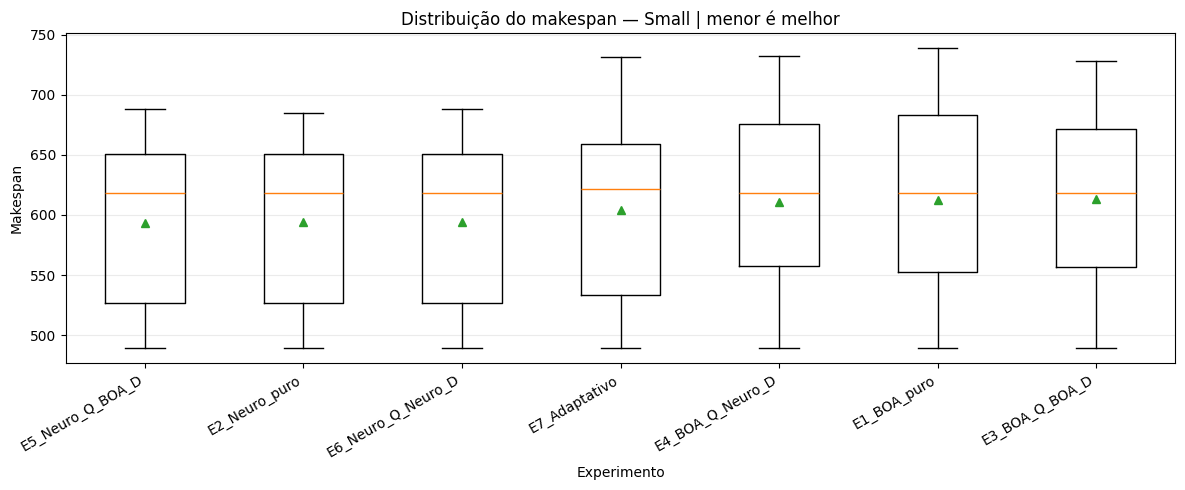

In [27]:

# ============================================================
# 21) BOXPLOT DO MAKESPAN
# ============================================================
def plot_makespan_boxplots(df):
    for group in df["group"].unique():
        sub=df[df["group"]==group]
        order=sub.groupby("experiment")["makespan"].mean().sort_values().index.tolist()
        data=[sub.loc[sub["experiment"]==e,"makespan"].values for e in order]
        plt.figure(figsize=(12,5))
        plt.boxplot(data,tick_labels=order,showmeans=True)
        plt.ylabel("Makespan")
        plt.xlabel("Experimento")
        plt.title(f"Distribuição do makespan — {group} | menor é melhor")
        plt.xticks(rotation=30,ha="right")
        plt.grid(axis="y",alpha=.25)
        plt.tight_layout(); plt.show()
plot_makespan_boxplots(df_results)



### Leitura do boxplot

Caixas mais baixas indicam melhor desempenho típico; caixas mais estreitas indicam maior estabilidade. Se o Adaptativo tiver a melhor execução, mas grande dispersão, isso deve ser relatado como ganho potencial com menor robustez.


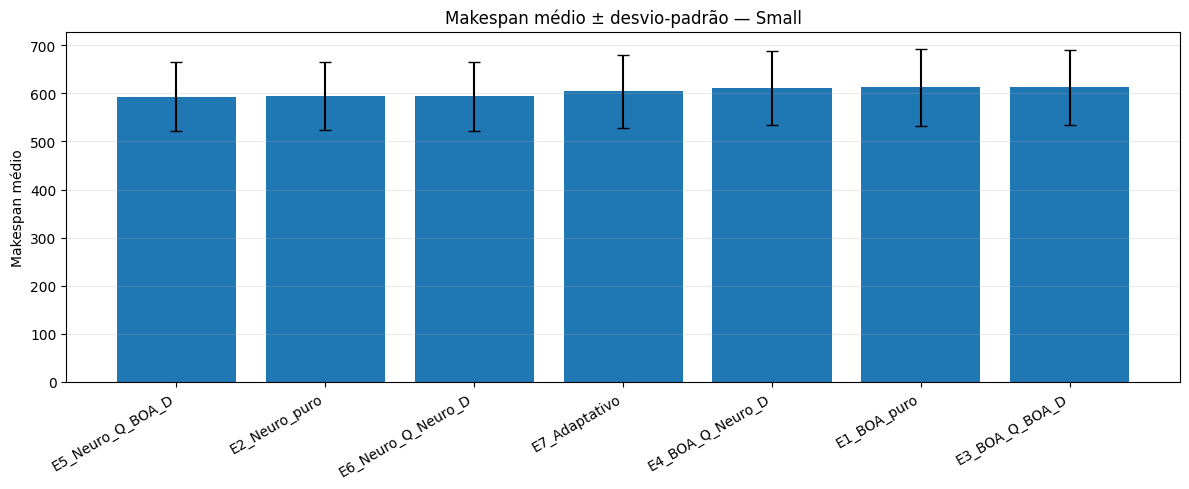

In [28]:

# ============================================================
# 22) MÉDIA ± DESVIO-PADRÃO
# ============================================================
def plot_mean_std(df):
    for group in df["group"].unique():
        s=df[df["group"]==group].groupby("experiment")["makespan"].agg(["mean","std"]).sort_values("mean")
        x=np.arange(len(s))
        plt.figure(figsize=(12,5))
        plt.bar(x,s["mean"],yerr=s["std"].fillna(0),capsize=4)
        plt.xticks(x,s.index,rotation=30,ha="right")
        plt.ylabel("Makespan médio")
        plt.title(f"Makespan médio ± desvio-padrão — {group}")
        plt.grid(axis="y",alpha=.25)
        plt.tight_layout(); plt.show()
plot_mean_std(df_results)


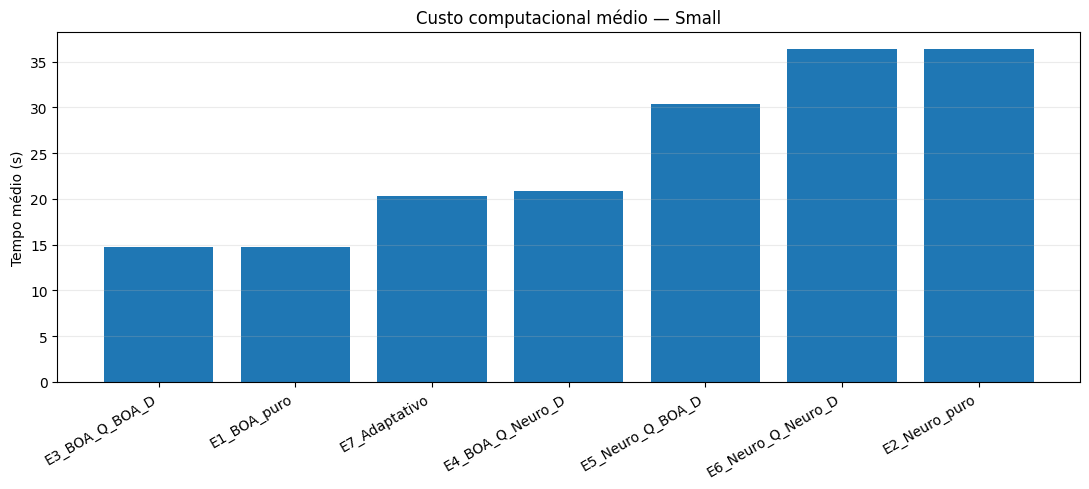

In [29]:

# ============================================================
# 23) TEMPO COMPUTACIONAL
# ============================================================
def plot_runtime(df):
    s=df.groupby(["group","experiment"])["time_s"].mean().reset_index()
    for group in s["group"].unique():
        sub=s[s["group"]==group].sort_values("time_s")
        plt.figure(figsize=(11,5))
        plt.bar(sub["experiment"],sub["time_s"])
        plt.ylabel("Tempo médio (s)")
        plt.title(f"Custo computacional médio — {group}")
        plt.xticks(rotation=30,ha="right")
        plt.grid(axis="y",alpha=.25)
        plt.tight_layout(); plt.show()
plot_runtime(df_results)



### Qualidade × custo

A proposta adaptativa executa sondagens dos dois geradores, treina modelos de qualidade/diversidade e ainda treina seletores. Por isso, ela pode ser mais lenta.


Ranking médio (1 = melhor):


,group,experiment,mean,std,count
1,Small,E2_Neuro_puro,2.54,1.177,50
4,Small,E5_Neuro_Q_BOA_D,2.57,0.985,50
5,Small,E6_Neuro_Q_Neuro_D,2.74,1.250,50
6,Small,E7_Adaptativo,4.39,1.386,50
3,Small,E4_BOA_Q_Neuro_D,5.17,1.483,50
0,Small,E1_BOA_puro,5.22,1.529,50
2,Small,E3_BOA_Q_BOA_D,5.37,1.446,50


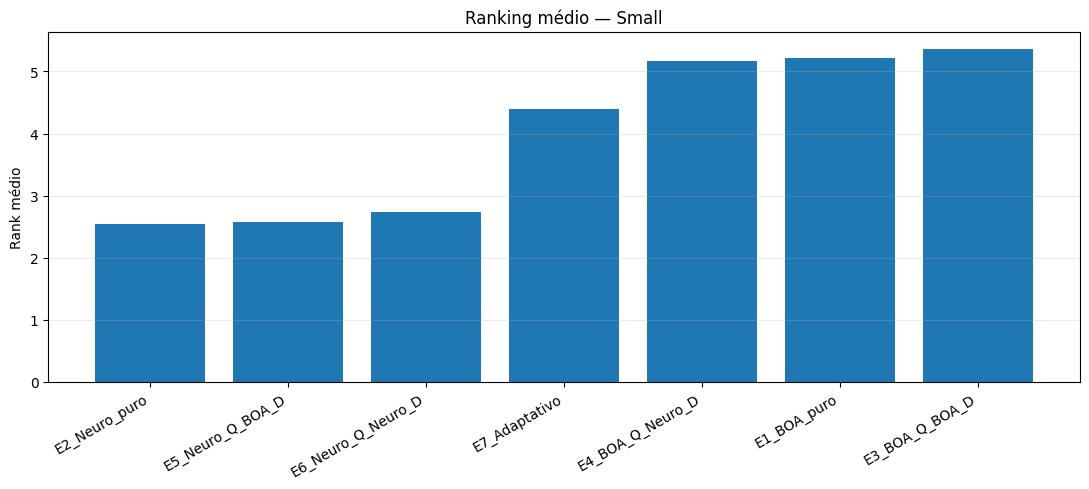

In [30]:

# ============================================================
# 24) RANKING MÉDIO
# ============================================================
def compute_ranks(df):
    x=df.copy()
    x["rank"]=x.groupby(["instance","seed"])["makespan"].rank(method="average",ascending=True)
    return x
rank_df=compute_ranks(df_results)
rank_summary=(rank_df.groupby(["group","experiment"])["rank"].agg(["mean","std","count"]).reset_index().sort_values(["group","mean"]))
print("Ranking médio (1 = melhor):")
display(rank_summary.round(3))
for group in rank_summary["group"].unique():
    sub=rank_summary[rank_summary["group"]==group].sort_values("mean")
    plt.figure(figsize=(11,5)); plt.bar(sub["experiment"],sub["mean"])
    plt.ylabel("Rank médio"); plt.title(f"Ranking médio — {group}")
    plt.xticks(rotation=30,ha="right"); plt.grid(axis="y",alpha=.25); plt.tight_layout(); plt.show()


Vitórias por instância:


,group,experiment,vitorias
0,Small,E2_Neuro_puro,3
1,Small,E4_BOA_Q_Neuro_D,1
2,Small,E5_Neuro_Q_BOA_D,2
3,Small,E6_Neuro_Q_Neuro_D,1


Gap relativo ao melhor método de cada instância:


,group,experiment,mean,median,std
4,Small,E5_Neuro_Q_BOA_D,0.139,0.020,0.235
5,Small,E6_Neuro_Q_Neuro_D,0.294,0.226,0.281
1,Small,E2_Neuro_puro,0.322,0.000,0.606
6,Small,E7_Adaptativo,2.015,1.413,1.696
3,Small,E4_BOA_Q_Neuro_D,3.131,2.965,2.650
0,Small,E1_BOA_puro,3.361,3.702,2.561
2,Small,E3_BOA_Q_BOA_D,3.427,2.581,3.147


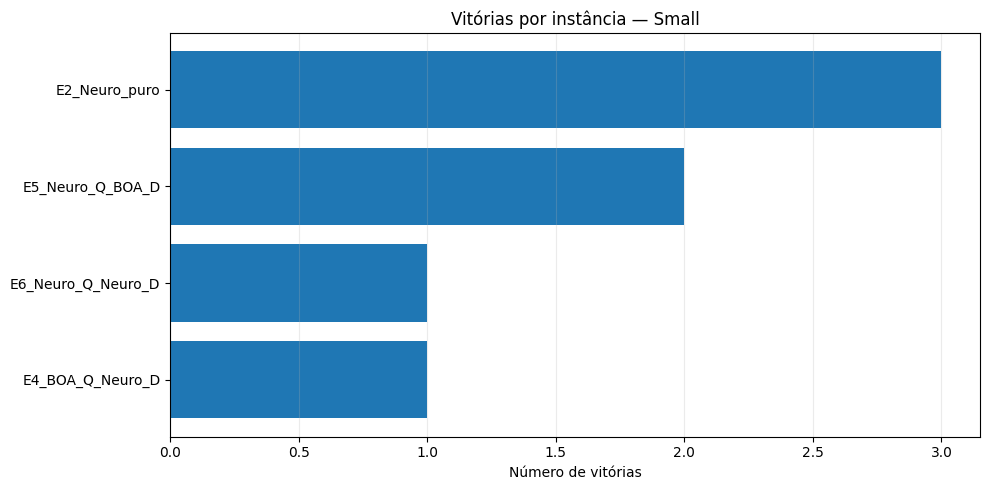

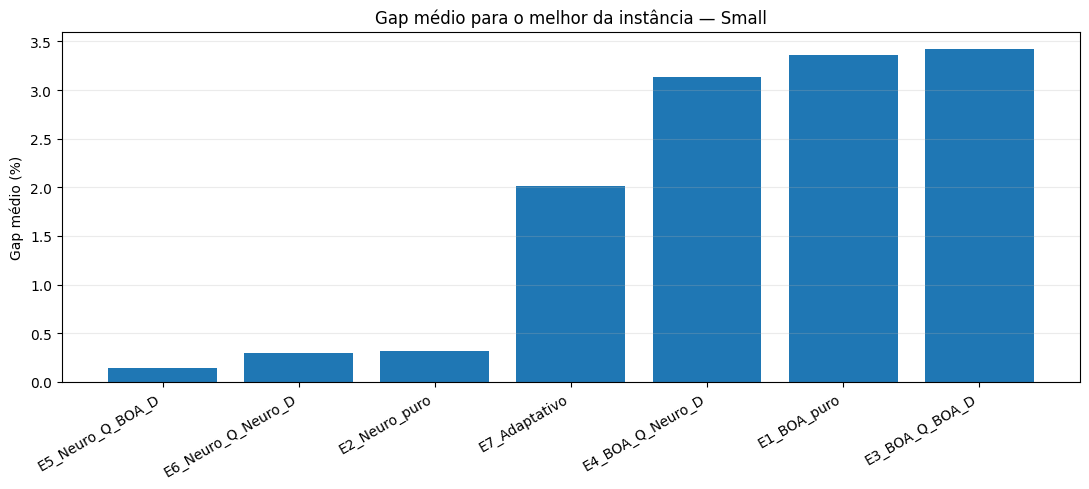

In [31]:

# ============================================================
# 25) VITÓRIAS POR INSTÂNCIA E GAP RELATIVO
# ============================================================
def win_and_gap(df):
    means=df.groupby(["group","instance","experiment"])["makespan"].mean().reset_index()
    best=means.groupby(["group","instance"])["makespan"].transform("min")
    means["winner"]=np.isclose(means["makespan"],best)
    means["gap_%"]=100*(means["makespan"]-best)/best
    wins=(means[means["winner"]].groupby(["group","experiment"]).size().rename("vitorias").reset_index())
    gaps=(means.groupby(["group","experiment"])["gap_%"].agg(["mean","median","std"]).reset_index().sort_values(["group","mean"]))
    return means,wins,gaps

gap_detail,wins_df,gap_summary=win_and_gap(df_results)
print("Vitórias por instância:"); display(wins_df)
print("Gap relativo ao melhor método de cada instância:"); display(gap_summary.round(3))

for group in wins_df["group"].unique():
    sub=wins_df[wins_df["group"]==group].sort_values("vitorias")
    plt.figure(figsize=(10,5)); plt.barh(sub["experiment"],sub["vitorias"])
    plt.xlabel("Número de vitórias"); plt.title(f"Vitórias por instância — {group}")
    plt.grid(axis="x",alpha=.25); plt.tight_layout(); plt.show()

for group in gap_summary["group"].unique():
    sub=gap_summary[gap_summary["group"]==group].sort_values("mean")
    plt.figure(figsize=(11,5)); plt.bar(sub["experiment"],sub["mean"])
    plt.ylabel("Gap médio (%)"); plt.title(f"Gap médio para o melhor da instância — {group}")
    plt.xticks(rotation=30,ha="right"); plt.grid(axis="y",alpha=.25); plt.tight_layout(); plt.show()



### Interpretação do gap

Em cada instância, o melhor resultado médio recebe `0%`. Os demais indicam quanto ficaram acima dele. Essa métrica é útil para comparar problemas de escalas diferentes.


In [32]:

# ============================================================
# 26) TESTES ESTATÍSTICOS
# ============================================================
def friedman_results(df):
    rows=[]
    for group in df["group"].unique():
        p=df[df["group"]==group].pivot_table(index=["instance","seed"],columns="experiment",values="makespan",aggfunc="mean").dropna()
        if p.shape[0]>=2 and p.shape[1]>=3:
            stat,pv=friedmanchisquare(*[p[c].values for c in p.columns])
        else: stat,pv=np.nan,np.nan
        rows.append({"group":group,"n_blocos":p.shape[0],"n_metodos":p.shape[1],"chi2":stat,"p_value":pv})
    return pd.DataFrame(rows)

def wilcoxon_vs_adaptive(df,adaptive="E7_Adaptativo"):
    rows=[]
    if adaptive not in set(df["experiment"]): return pd.DataFrame()
    for group in df["group"].unique():
        p=df[df["group"]==group].pivot_table(index=["instance","seed"],columns="experiment",values="makespan",aggfunc="mean")
        if adaptive not in p.columns: continue
        for other in p.columns:
            if other==adaptive: continue
            pair=p[[adaptive,other]].dropna()
            if len(pair)<5: continue
            diff=pair[adaptive]-pair[other]
            if np.allclose(diff,0): stat,pv=0.0,1.0
            else: stat,pv=wilcoxon(pair[adaptive],pair[other],alternative="two-sided")
            rows.append({"group":group,"comparacao":f"{adaptive} vs {other}","n_pares":len(pair),"diferenca_media":diff.mean(),"W":stat,"p_value":pv})
    out=pd.DataFrame(rows)
    if len(out):
        out=out.sort_values("p_value").reset_index(drop=True)
        m=len(out); out["p_holm"]=[min(1.0,p*(m-i)) for i,p in enumerate(out["p_value"])]
    return out

friedman_df=friedman_results(df_results)
wilcoxon_df=wilcoxon_vs_adaptive(df_results)
print("Friedman — H0: todos os métodos têm desempenho equivalente")
display(friedman_df.round(6))
print("Wilcoxon pareado contra o Adaptativo (diferença média < 0 favorece o Adaptativo)")
display(wilcoxon_df.round(6))


Friedman — H0: todos os métodos têm desempenho equivalente


,group,n_blocos,n_metodos,chi2,p_value
0,Small,50,7,139.707914,0.0


Wilcoxon pareado contra o Adaptativo (diferença média < 0 favorece o Adaptativo)


,group,comparacao,n_pares,diferenca_media,W,p_value,p_holm
0,Small,E7_Adaptativo vs E5_Neuro_Q_BOA_D,50,11.20,10.0,0.000000,0.000002
1,Small,E7_Adaptativo vs E2_Neuro_puro,50,10.36,40.0,0.000007,0.000033
2,Small,E7_Adaptativo vs E6_Neuro_Q_Neuro_D,50,10.36,64.5,0.000040,0.000160
3,Small,E7_Adaptativo vs E3_BOA_Q_BOA_D,50,-8.40,171.0,0.002235,0.006704
4,Small,E7_Adaptativo vs E1_BOA_puro,50,-8.36,193.5,0.003600,0.007200
5,Small,E7_Adaptativo vs E4_BOA_Q_Neuro_D,50,-6.56,293.0,0.018346,0.018346


In [33]:

# ============================================================
# 27) ANÁLISE DETALHADA DE UMA EXECUÇÃO ADAPTATIVA
# ============================================================
def analyze_adaptive_run(result):
    h=result["history"].copy()
    print(f"Instância: {result['instance']} | Melhor makespan: {result['best_makespan']} | Atraso total: {result['best_total_tardiness']}")

    plt.figure(figsize=(9,4)); plt.plot(h["generation"],h["best"],label="Melhor"); plt.plot(h["generation"],h["mean"],label="Média")
    plt.xlabel("Geração"); plt.ylabel("Makespan"); plt.title("Convergência da população"); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,4)); plt.plot(h["generation"],h["diversity"])
    plt.xlabel("Geração"); plt.ylabel("Diversidade média"); plt.title("Evolução da diversidade"); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

    q_share=(h["quality_choice"]=="NEURO").expanding().mean()*100
    d_share=(h["diversity_choice"]=="NEURO").expanding().mean()*100
    plt.figure(figsize=(9,4)); plt.plot(h["generation"],q_share,label="Neuro-Q"); plt.plot(h["generation"],d_share,label="Neuro-D")
    plt.ylim(0,100); plt.xlabel("Geração"); plt.ylabel("Seleções acumuladas do Neuro (%)"); plt.title("Preferência acumulada das meta-redes"); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,4)); plt.plot(h["generation"],h["q_score_boa"],label="BOA-Q"); plt.plot(h["generation"],h["q_score_neuro"],label="Neuro-Q")
    plt.xlabel("Geração"); plt.ylabel("Escore"); plt.title("Probes de qualidade"); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,4)); plt.plot(h["generation"],h["d_score_boa"],label="BOA-D"); plt.plot(h["generation"],h["d_score_neuro"],label="Neuro-D")
    plt.xlabel("Geração"); plt.ylabel("Escore"); plt.title("Probes de diversidade útil"); plt.legend(); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

    print("Escolhas para qualidade:"); display(h["quality_choice"].value_counts().rename("gerações").to_frame())
    print("Escolhas para diversidade:"); display(h["diversity_choice"].value_counts().rename("gerações").to_frame())

# Exemplo após uma execução adaptativa:
# analyze_adaptive_run(result)
# Ou após benchmark:
# analyze_adaptive_run(details[(nome_instancia, "E7_Adaptativo", seed)])


In [34]:
# ============================================================
# 28) RANKING POR INSTÂNCIA SMALL
# ============================================================
def compare_small_instances(df):
    r = (
        compute_ranks(df)
        .groupby(["instance", "experiment"])["rank"]
        .mean()
        .unstack("instance")
    )

    print("Rank médio por instância Small:")
    display(r.round(3))

compare_small_instances(df_results)


Rank médio por instância Small:


instance,I_2_10_2_1.txt,I_2_10_2_2.txt,I_2_10_2_3.txt,I_2_10_2_4.txt,I_2_10_2_5.txt
experiment,,,,,
E1_BOA_puro,5.85,4.75,6.30,4.35,4.85
E2_Neuro_puro,1.70,3.45,2.30,2.55,2.70
E3_BOA_Q_BOA_D,6.05,4.05,5.50,5.20,6.05
E4_BOA_Q_Neuro_D,5.05,3.45,5.75,5.95,5.65
E5_Neuro_Q_BOA_D,2.25,3.45,2.15,2.75,2.25
E6_Neuro_Q_Neuro_D,2.55,3.55,1.95,3.20,2.45
E7_Adaptativo,4.55,5.30,4.05,4.00,4.05


In [35]:
# ============================================================
# 29) CONCLUSÃO FINAL AUTOMÁTICA
# ============================================================
def final_conclusion(df):
    ranks = compute_ranks(df).groupby("experiment")["rank"].mean().sort_values()
    stats = df.groupby("experiment").agg(
        makespan_medio=("makespan", "mean"),
        mediana=("makespan", "median"),
        std=("makespan", "std"),
        tempo_medio=("time_s", "mean"),
        melhor=("makespan", "min")
    )

    best_rank = ranks.index[0]
    best_mean = stats["makespan_medio"].idxmin()

    print("=" * 80)
    print("CONCLUSÃO FINAL")
    print("=" * 80)
    print(f"\nMelhor ranking médio: {best_rank} (rank={ranks.iloc[0]:.3f}).")
    print(f"Menor makespan médio absoluto: {best_mean} ({stats.loc[best_mean, 'makespan_medio']:.3f}).")

    adaptive = "E7_Adaptativo"
    if adaptive in ranks.index:
        fixed = [x for x in ranks.index if x != adaptive]
        best_fixed = ranks.loc[fixed].idxmin()
        print(f"\nAdaptativo: rank={ranks.loc[adaptive]:.3f}, makespan médio={stats.loc[adaptive, 'makespan_medio']:.3f}, tempo médio={stats.loc[adaptive, 'tempo_medio']:.3f}s.")
        print(f"Melhor configuração fixa: {best_fixed} (rank={ranks.loc[best_fixed]:.3f}).")

        if ranks.loc[adaptive] < ranks.loc[best_fixed]:
            print("A seleção adaptativa superou a melhor configuração fixa em ranking médio.")
        elif np.isclose(ranks.loc[adaptive], ranks.loc[best_fixed]):
            print("A seleção adaptativa ficou praticamente empatada com a melhor configuração fixa.")
        else:
            print("A melhor configuração fixa superou o Adaptativo no ranking médio destas instâncias.")

    fr = friedman_results(df)
    pv = fr["p_value"].dropna()
    if len(pv):
        if (pv < 0.05).all():
            print("\nFriedman: há evidência de diferenças entre os métodos (p < 0,05).")
        else:
            print("\nFriedman: não houve diferença estatisticamente significativa em todos os casos avaliáveis.")

    print("\nInterpretação da diversidade:")
    print("As variantes com BOA-D/Neuro-D devem manter diversidade útil sem degradar excessivamente o makespan.")
    print("\nInterpretação do custo:")
    print("O Adaptativo deve ser avaliado considerando o custo adicional de probes, treinamento e seleção.")

final_conclusion(df_results)



CONCLUSÃO FINAL

Melhor ranking médio: E2_Neuro_puro (rank=2.540).
Menor makespan médio absoluto: E5_Neuro_Q_BOA_D (593.240).

Adaptativo: rank=4.390, makespan médio=604.440, tempo médio=20.356s.
Melhor configuração fixa: E2_Neuro_puro (rank=2.540).
A melhor configuração fixa superou o Adaptativo no ranking médio destas instâncias.

Friedman: há evidência de diferenças entre os métodos (p < 0,05).

Interpretação da diversidade:
As variantes com BOA-D/Neuro-D devem manter diversidade útil sem degradar excessivamente o makespan.

Interpretação do custo:
O Adaptativo deve ser avaliado considerando o custo adicional de probes, treinamento e seleção.
